 
<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> Feature Engineering - Missing value Hanadling </h2>
</div>


- Here  **feature_engine.missing_data_imputers** is not installed so used **feature_engine.imputation**
- If we are applying any Numerical imputation, then we need to convert obj to numerical variable 1st
  -  data['cabin'].astype(int)



### 1. Numerical Variable Imputation

##### 1.1 FILLNA with median() or mean()  abitary  etc 
- It Replaces Null/NA value by hardcoded value or mean or median whichever we are passing in fillna function


##### 1.2 1.2 Simple Imputer -  mean OR median or abitary value for Numeric
- It Replaces Null/NA value by hardcoded value or mean or median whichever we are passing in Simpleimputer function

##### 1.3. MeanMedianImputer 
- The MeanMedianImputer() replaces missing data with the mean or median of the variable.

- It works only with numerical variables. A list of variables to impute can be indicated, or the imputer will automatically select all numerical variables in the train set.

##### 1.4. ArbitraryNumberImputer ¶
- Here hardcoding with some user defined value (-999)

- The ArbitraryNumberImputer() replaces missing data with an arbitrary value determined by the user.

- It works only with numerical variables. A list of variables can be indicated, or the imputer will automatically select all numerical variables in the train set.

- A dictionary with variables and their arbitrary values can be indicated to use different arbitrary values for variables.


##### 1.5. EndTail Imputer 
- The EndTailImputer() replaces missing data by a value at either tail of the distribution. It works only with numerical variables.

- You can indicate the variables to be imputed in a list. Alternatively, the EndTailImputer() will automatically find and select all variables of type numeric.

> Gaussian limits: - right tail: mean + 3std - left tail: mean - 3std

> IQR limits: - right tail: 75th quantile + 3*IQR

        - left tail: 25th quantile - 3*IQR

        - where IQR is the inter-quartile range = 75th quantile - 25th quantile
> Maximum value: - right tail: max * 3

        - left tail: not applicable


### 2. Categorical Variable Imputation 

##### 2.1 Categorical Variable Imputer 
- This CategoricalImputer imputer used only for categorical data

- Here it replaces catrgorical value having null to an arbitrary value 'Missing' or by the most frequent category.


### 3. Numerical or Categorical Variable Imputer

##### 3.1 Random Sample Imputer 
- classfeature_engine.imputation.RandomSampleImputer(random_state=None, seed='general', seeding_method='add', variables=None)

- The RandomSampleImputer() replaces missing data with a random sample extracted from the variable.

- It works with both numerical and categorical variables. A list of variables can be indicated, or the imputer will automatically select all variables in the train set.

##### 3.2 Add Missing Indicator 

- It adds binary indicator as new col

- This method doesn't changes/updates any value in existing column, instead it creates the new column with missing indicator




### Note: 
This whole FE tutorla is followed from below link.

#https://feature-engine.readthedocs.io/en/latest/index.html
    

Feature-Engine is an python library in which APIs/Functions are designed in a very user friendly way to achieve
the feature engineering.

 
<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> Import Libraries </h2>
</div>


In [254]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import feature_engine.imputation  as mdi
#import feature_engine.missing_data_imputers as mdi

from sklearn.impute import SimpleImputer

- pip install -U feature-engine

In [255]:
# Load the data set

df = pd.read_csv('./Dataset/houseprice.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Check Missing Values

In [256]:
## Here we will check the percentage of nan values present in each feature
## 1 -step make the list of features which has missing values, it includes both numeric and Categorical features

features_with_na=[features for features in df.columns if df[features].isnull().sum()>1]


## 2- step print the feature name and the percentage of missing values

# Here mean will give mean value based on [No of isnull() record]/ [Total no of record]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean(), 4),  ' % missing values')

LotFrontage 0.1774  % missing values
Alley 0.9377  % missing values
MasVnrType 0.0055  % missing values
MasVnrArea 0.0055  % missing values
BsmtQual 0.0253  % missing values
BsmtCond 0.0253  % missing values
BsmtExposure 0.026  % missing values
BsmtFinType1 0.0253  % missing values
BsmtFinType2 0.026  % missing values
FireplaceQu 0.4726  % missing values
GarageType 0.0555  % missing values
GarageYrBlt 0.0555  % missing values
GarageFinish 0.0555  % missing values
GarageQual 0.0555  % missing values
GarageCond 0.0555  % missing values
PoolQC 0.9952  % missing values
Fence 0.8075  % missing values
MiscFeature 0.963  % missing values


>  Since they are many missing values, we need to find the relationship between missing values and Sales Price

Let's plot some diagram for this relationship

LotFrontage
0    159500
1    172400
Name: SalePrice, dtype: int64


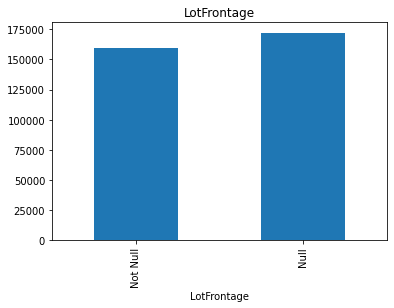

Alley
0    140000
1    165000
Name: SalePrice, dtype: int64


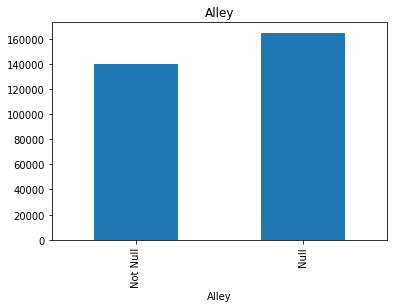

MasVnrType
0    162700
1    203287
Name: SalePrice, dtype: int64


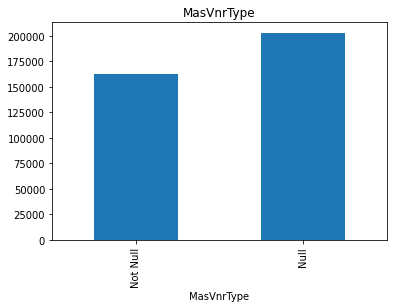

MasVnrArea
0    162700
1    203287
Name: SalePrice, dtype: int64


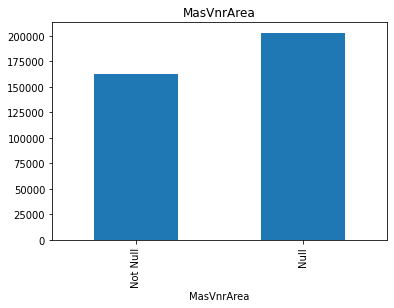

BsmtQual
0    165000
1    101800
Name: SalePrice, dtype: int64


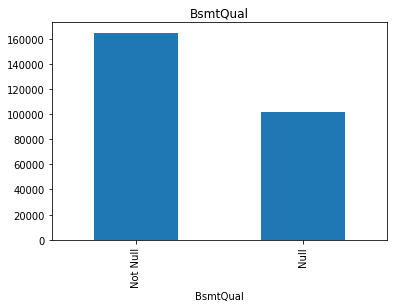

BsmtCond
0    165000
1    101800
Name: SalePrice, dtype: int64


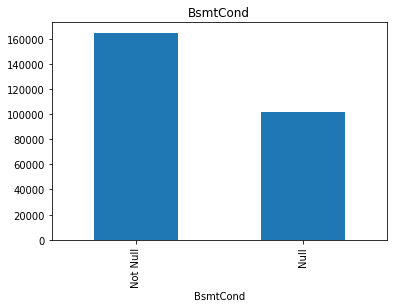

BsmtExposure
0    165000
1    104025
Name: SalePrice, dtype: int64


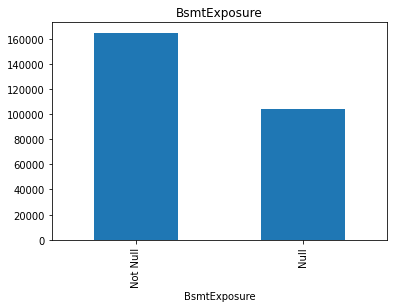

BsmtFinType1
0    165000
1    101800
Name: SalePrice, dtype: int64


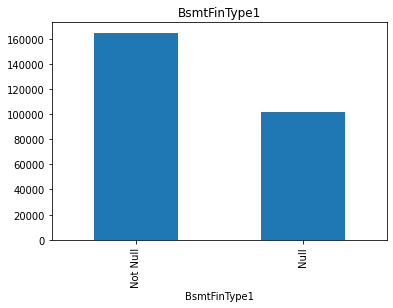

BsmtFinType2
0    165000
1    104025
Name: SalePrice, dtype: int64


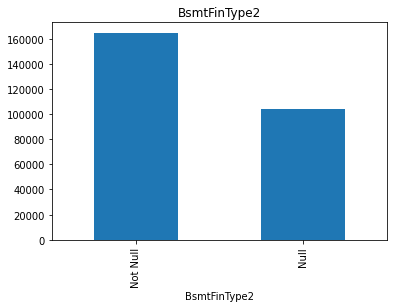

FireplaceQu
0    191000
1    135000
Name: SalePrice, dtype: int64


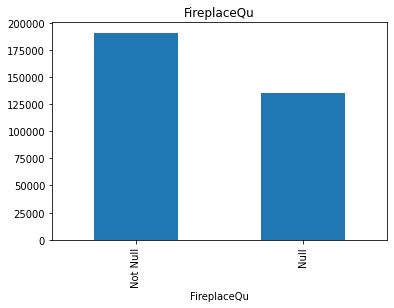

GarageType
0    167500
1    100000
Name: SalePrice, dtype: int64


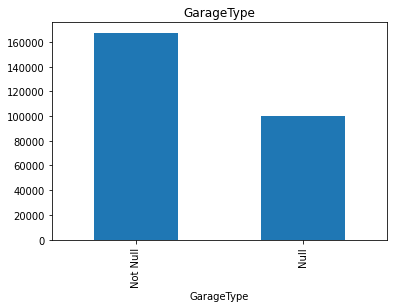

GarageYrBlt
0    167500
1    100000
Name: SalePrice, dtype: int64


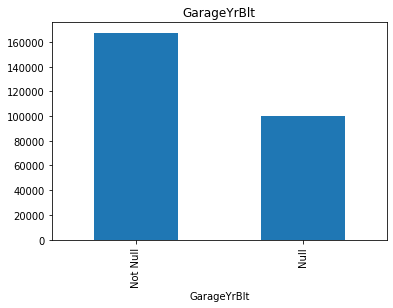

GarageFinish
0    167500
1    100000
Name: SalePrice, dtype: int64


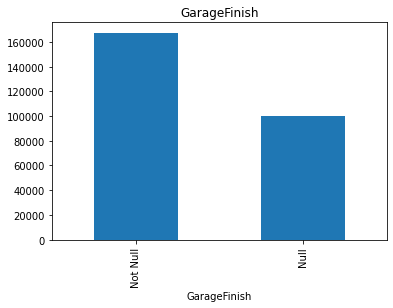

GarageQual
0    167500
1    100000
Name: SalePrice, dtype: int64


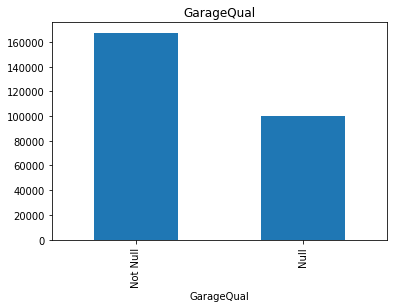

GarageCond
0    167500
1    100000
Name: SalePrice, dtype: int64


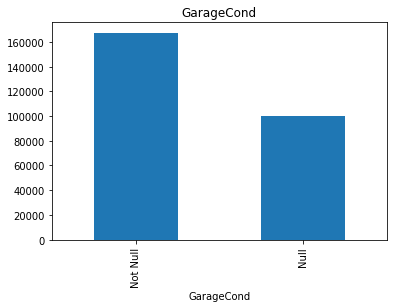

PoolQC
0    235000
1    162900
Name: SalePrice, dtype: int64


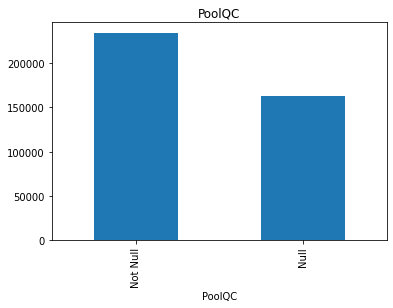

Fence
0    141500
1    173000
Name: SalePrice, dtype: int64


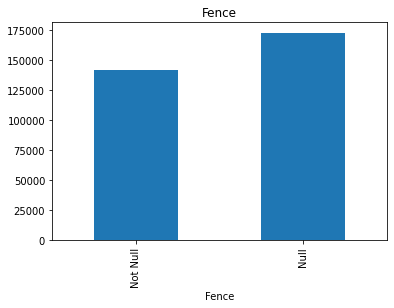

MiscFeature
0    146000
1    164250
Name: SalePrice, dtype: int64


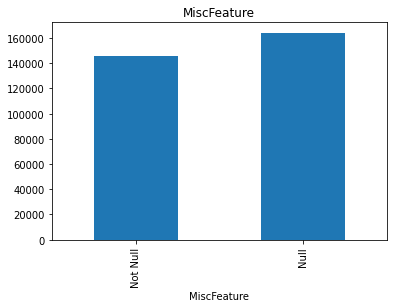

In [257]:
for feature in features_with_na:
    data = df.copy()
    
    # let's make a variable that indicates 1 if the observation was missing or zero otherwise
    #Here it replaces specific feature value by 0 or 1, if null then 1,else 0
    
    data[feature] = np.where(data[feature].isnull(), 1, 0)
    
    # let's calculate the mean SalePrice where the information is missing(1) or present(0)
    
    print(data.groupby(feature)['SalePrice'].median())
    data.groupby(feature)['SalePrice'].median().plot.bar()
    plt.title(feature)
    plt.xticks([0,1],['Not Null', 'Null'])
    plt.show()

In [258]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [259]:
# separate the train test dataset

x_train, x_test, y_train, y_test = train_test_split(df.drop(['SalePrice'],axis =1), df['SalePrice'],
                                                    test_size = 0.3, random_state=0)
                                                     


<div class="alert alert-info" style="background-color:#002292; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1. Numerical Variable Imputation </h2>
</div>

In [260]:
## Now lets check for numerical variables the contains missing values
numerical_with_nan=[feature for feature in x_train.columns if x_train[feature].isnull().sum()>1 and x_train[feature].dtypes!='O']

## We will print the numerical nan variables and percentage of missing values

for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(x_train[feature].isnull().mean(),4)))

LotFrontage: 0.1849% missing value
MasVnrArea: 0.0049% missing value
GarageYrBlt: 0.0528% missing value


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1.1 FILLNA with median() or mean() etc </h2>
</div>

- It Replaces Null/NA value by **hardcoded value or mean or median** whichever we are passing in fillna function 

In [261]:
#We should not do direct copy (x_train_copy11 = x_train), like this we should do, else it replaces in original also
x_train_copy11 = x_train.copy()



for feature in numerical_with_nan:
    ## We will replace by using median since there are outliers
    median_value=x_train_copy11[feature].median()
    
    ## Here created a new feature to capture nan values like indicator, if 1 then null value, if 0 then non null
    x_train_copy11[feature+'nan']=np.where(x_train_copy11[feature].isnull(),1,0)
    
    x_train_copy11[feature] = x_train_copy11[feature].fillna(median_value)
    
x_train_copy11[numerical_with_nan].isnull().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [262]:
x_train[numerical_with_nan].isnull().sum()

LotFrontage    189
MasVnrArea       5
GarageYrBlt     54
dtype: int64


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1.2 Simple Imputer -  mean OR median or abitary value for Numeric </h2>
</div>

In [263]:
# Create Main DF:
data = {'name': ['abc1', 'abc2', 'abc3', 'abc4', 'abc5', 'abc6','abc7', 'abc8', 'abc9', 'abc10'], 
        'age': [10, 15, None, 25, 30, None ,40,45, None,50],
'sex': ['male','female','male','female','male','female','male','female','male','female'],
'sal': [100,200,300,None,500,600,None,800,900,1000]
       }

traindf = pd.DataFrame(data)
traindf

,name,age,sex,sal
0,abc1,10.0,male,100.0
1,abc2,15.0,female,200.0
2,abc3,NaN,male,300.0
3,abc4,25.0,female,NaN
4,abc5,30.0,male,500.0
5,abc6,NaN,female,600.0
6,abc7,40.0,male,NaN
7,abc8,45.0,female,800.0
8,abc9,NaN,male,900.0
9,abc10,50.0,female,1000.0


In [264]:
traindf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    10 non-null     object 
 1   age     7 non-null      float64
 2   sex     10 non-null     object 
 3   sal     8 non-null      float64
dtypes: float64(2), object(2)
memory usage: 448.0+ bytes


In [265]:
traindf.isnull().sum()

name    0
age     3
sex     0
sal     2
dtype: int64

> There is a null values in age,sal 

In [266]:
# Create the imputer, the strategy can be mean and median.

imputer = SimpleImputer(missing_values=np.nan, strategy='mean') #by default also 'mean' strategy is used.
imputer.fit(traindf.loc[:,['age','sal']])  

# Same replaces by median
# imputer = SimpleImputer(missing_values=np.nan, strategy='median')

# Replaces arbitary value
# imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=999)

SimpleImputer()

In [267]:
traindf.loc[:,['age','sal']] = imputer.transform(traindf.loc[:,['age','sal']])  
traindf


,name,age,sex,sal
0,abc1,10.000000,male,100.0
1,abc2,15.000000,female,200.0
2,abc3,30.714286,male,300.0
3,abc4,25.000000,female,550.0
4,abc5,30.000000,male,500.0
5,abc6,30.714286,female,600.0
6,abc7,40.000000,male,550.0
7,abc8,45.000000,female,800.0
8,abc9,30.714286,male,900.0
9,abc10,50.000000,female,1000.0


In [268]:
traindf.isnull().sum()
#below we can see mean value is applied in age AND sal column whereever null was there.

# This applied to both test and train data

name    0
age     0
sex     0
sal     0
dtype: int64


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1.2. MeanMedianImputer </h2>
</div>


- classfeature_engine.imputation.MeanMedianImputer(imputation_method='median', variables=None)

- The MeanMedianImputer() replaces missing data with the **mean or median** of the variable. 
- It works only with numerical variables. A list of variables to impute can be indicated, or the imputer will automatically select all numerical variables in the train set.

In [269]:
for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(x_train[feature].isnull().mean(),4)))

LotFrontage: 0.1849% missing value
MasVnrArea: 0.0049% missing value
GarageYrBlt: 0.0528% missing value


In [270]:
#Data copy
x_train_copy1 = x_train.copy()

In [271]:
# set up the imputer

median_imputer = mdi.MeanMedianImputer(imputation_method='median',variables=numerical_with_nan)
#median_imputer = mdi.MeanMedianImputer(imputation_method='median',variables=['LotFrontage','MasVnrArea'])
median_imputer

MeanMedianImputer(variables=['LotFrontage', 'MasVnrArea', 'GarageYrBlt'])

In [272]:
#fit the imputer
median_imputer.fit(x_train_copy1)

# transform the data
train_1 = median_imputer.transform(x_train_copy1)
#test_1 = median_imputer.transform(x_test)

In [273]:
# The dictionary containing the mean / median values per variable. 
#These values will be used by the imputer to replace missing data.

median_imputer.imputer_dict_ 

{'LotFrontage': 69.0, 'MasVnrArea': 0.0, 'GarageYrBlt': 1979.0}

In [274]:
print(x_train.LotFrontage.median())
print(x_train.MasVnrArea.median())
print(x_train.GarageYrBlt.median())

69.0
0.0
1979.0


In [275]:
## Check is there any null values in numeric dataset after MeanMedianImputer
#train_1['LotFrontage'].isnull().sum()
#train_t['MasVnrArea'].isnull().sum()

for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_1[feature].isnull().mean(),4)))

LotFrontage: 0.0% missing value
MasVnrArea: 0.0% missing value
GarageYrBlt: 0.0% missing value


In [276]:
train_1[train_1.Id.isin([65,683])]  # randomly selected 2 rows to see the result. 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
64,65,60,RL,69.0,9375,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,NaN,0,2,2009,WD,Normal
682,683,120,RL,69.0,2887,Pave,NaN,Reg,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,11,2008,WD,Normal


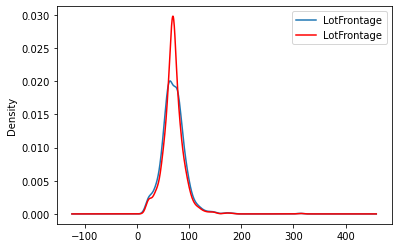

In [277]:
fig = plt.figure()
ax = fig.add_subplot(111)
x_train['LotFrontage'].plot(kind='kde', ax=ax)
train_1['LotFrontage'].plot(kind='kde', ax=ax, color='red')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

> Here count/density in median value is too high

<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1.3. ArbitraryNumberImputer </h2>
</div>

- Here hardcoding with some user defined value (-999)

- The ArbitraryNumberImputer() replaces missing data with an **arbitrary value** determined by the user. 
- It works only with **numerical variables**. A list of variables can be indicated, or the imputer will automatically select all numerical variables in the train set. 
- A dictionary with variables and their arbitrary values can be indicated to use different arbitrary values for variables.

In [278]:
#Data copy
x_train_copy2 = x_train.copy()

In [279]:
# set up the imputer
#arbitrary_imputer = mdi.ArbitraryNumberImputer( arbitrary_number=-999, variables=['LotFrontage', 'MasVnrArea'])
arbitrary_imputer = mdi.ArbitraryNumberImputer( arbitrary_number=-999, 
                                               variables=numerical_with_nan )

# fit the imputer
arbitrary_imputer.fit(x_train_copy2)

# transform the data
train_2= arbitrary_imputer.transform(x_train_copy2)
#test_t= arbitrary_imputer.transform(X_test)

In [280]:
arbitrary_imputer.imputer_dict_ 

{'LotFrontage': -999, 'MasVnrArea': -999, 'GarageYrBlt': -999}

In [281]:
## Check is there any null values in numeric dataset after ArbitraryNumberImputer
#train_2['LotFrontage'].isnull().sum()

for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_2[feature].isnull().mean(),4)))

LotFrontage: 0.0% missing value
MasVnrArea: 0.0% missing value
GarageYrBlt: 0.0% missing value


In [282]:
#train_2['LotFrontage'].value_counts() #189 row are updated with -999 value

<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 1.4. EndTail Imputer </h2>
</div>

- classfeature_engine.imputation.EndTailImputer(imputation_method='gaussian', tail='right', fold=3, variables=None)

- The EndTailImputer() replaces missing data by **a value at either tail of the distribution**. It works only with numerical variables.

- You can indicate the variables to be imputed in a list. Alternatively, the EndTailImputer() will automatically find and select all variables of type numeric.

> Gaussian limits:
            - right tail: mean + 3*std
            - left tail: mean - 3*std


> IQR limits:
            - right tail: 75th quantile + 3*IQR

            - left tail: 25th quantile - 3*IQR

            - where IQR is the inter-quartile range = 75th quantile - 25th quantile

> Maximum value:
            - right tail: max * 3

            - left tail: not applicable

In [283]:
#Data copy
x_train_copy3 = x_train.copy()

In [284]:
# set up the imputer

#tail_imputer = mdi.EndTailImputer(distribution='gaussian', tail='right', fold=3, variables=['LotFrontage', 'MasVnrArea'])
tail_imputer = mdi.EndTailImputer(distribution='gaussian',
                          tail='right',
                          fold=3,
                          variables= numerical_with_nan )

# fit the imputer
tail_imputer.fit(x_train_copy3)

# transform the data
train_3= tail_imputer.transform(x_train_copy3)
#test_t= tail_imputer.transform(X_test)

TypeError: __init__() got an unexpected keyword argument 'distribution'

In [ ]:
tail_imputer.imputer_dict_ 

In [ ]:
## Check is there any null values in numeric dataset after EndTailImputer
#train_2['LotFrontage'].isnull().sum()
#train_2['MasVnrArea'].isnull().sum()

for feature in numerical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_3[feature].isnull().mean(),4)))


<div class="alert alert-info" style="background-color:#002292; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 2. Categorical Variable Imputation </h2>
</div>


In [285]:
## Now lets check for numerical variables the contains missing values
categorical_with_nan=[feature for feature in x_train.columns if x_train[feature].isnull().sum()>1 and x_train[feature].dtypes =='O']

## We will print the numerical nan variables and percentage of missing values

for feature in categorical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(x_train[feature].isnull().mean(),4)))

Alley: 0.9393% missing value
MasVnrType: 0.0049% missing value
BsmtQual: 0.0235% missing value
BsmtCond: 0.0235% missing value
BsmtExposure: 0.0235% missing value
BsmtFinType1: 0.0235% missing value
BsmtFinType2: 0.0245% missing value
FireplaceQu: 0.4677% missing value
GarageType: 0.0528% missing value
GarageFinish: 0.0528% missing value
GarageQual: 0.0528% missing value
GarageCond: 0.0528% missing value
PoolQC: 0.9971% missing value
Fence: 0.8131% missing value
MiscFeature: 0.9569% missing value


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 2.1 Categorical Variable Imputer </h2>
</div>

- classfeature_engine.imputation.CategoricalImputer(imputation_method='missing', fill_value='Missing', variables=None, return_object=False, ignore_format=False)


- This CategoricalImputer imputer used only for categorical data
- Here it replaces catrgorical value having null to  an arbitrary value  **'Missing'** or by the most **frequent category**.


- The CategoricalVariableImputer() imputes by default only categorical variables (type ‘object’ or ‘categorical’). You can pass a list of variables to impute, or alternatively, the encoder will find and encode all categorical variables.

- If you want to impute numerical variables with this transformer, there are 2 ways of doing it:

> Option 1: Cast your numerical variables as object in the input dataframe, before passing it to the transformer.

> Option 2: Set ignore_format=True. Note that if you do this and do not pass the list of variables to impute, the imputer will automatically select and impute all variables in the dataframe.

In [286]:
#Data copy
x_train_copy4 = x_train.copy()

In [287]:
# set up the imputer
#imputer = mdi.CategoricalVariableImputer(variables=['Alley', 'MasVnrType']) # imputation_method (str, default=missing) 
#imputer = mdi.CategoricalVariableImputer(variables= categorical_with_nan) # imputation_method (str, default=missing) 

imputer = mdi.CategoricalImputer(variables= categorical_with_nan) # imputation_method (str, default=missing) 

#For frequent value replace
#imputer = CategoricalImputer(variables=['grade'], imputation_method='frequent')


# fit the imputer
imputer.fit(x_train_copy4)

# transform the data
train_4= imputer.transform(x_train_copy4)
#test_t= imputer.transform(X_test)

In [288]:
imputer.imputer_dict_ 

{'Alley': 'Missing',
 'MasVnrType': 'Missing',
 'BsmtQual': 'Missing',
 'BsmtCond': 'Missing',
 'BsmtExposure': 'Missing',
 'BsmtFinType1': 'Missing',
 'BsmtFinType2': 'Missing',
 'FireplaceQu': 'Missing',
 'GarageType': 'Missing',
 'GarageFinish': 'Missing',
 'GarageQual': 'Missing',
 'GarageCond': 'Missing',
 'PoolQC': 'Missing',
 'Fence': 'Missing',
 'MiscFeature': 'Missing'}

In [289]:
## Check is there any null values in categorical dataset after CategoricalImputer

for feature in categorical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_4[feature].isnull().mean(),4)))

Alley: 0.0% missing value
MasVnrType: 0.0% missing value
BsmtQual: 0.0% missing value
BsmtCond: 0.0% missing value
BsmtExposure: 0.0% missing value
BsmtFinType1: 0.0% missing value
BsmtFinType2: 0.0% missing value
FireplaceQu: 0.0% missing value
GarageType: 0.0% missing value
GarageFinish: 0.0% missing value
GarageQual: 0.0% missing value
GarageCond: 0.0% missing value
PoolQC: 0.0% missing value
Fence: 0.0% missing value
MiscFeature: 0.0% missing value


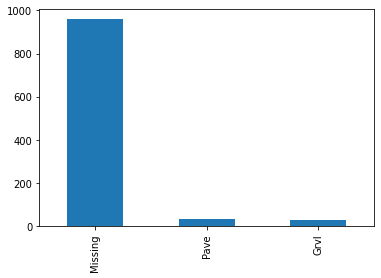

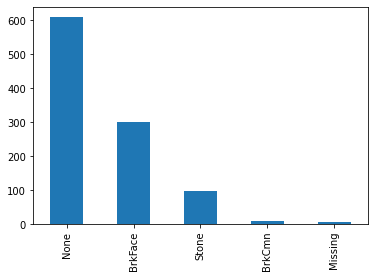

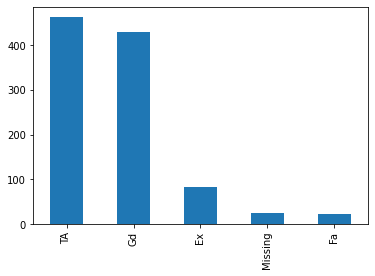

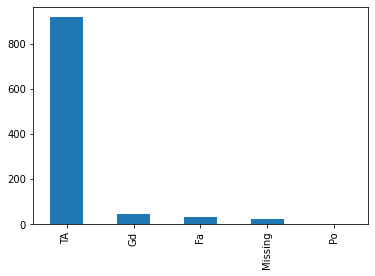

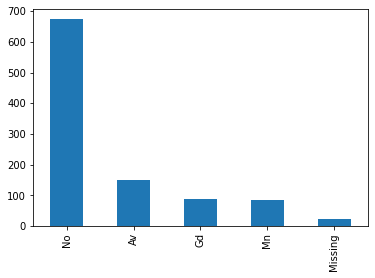

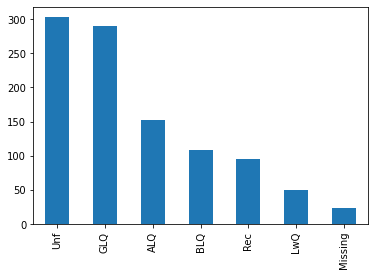

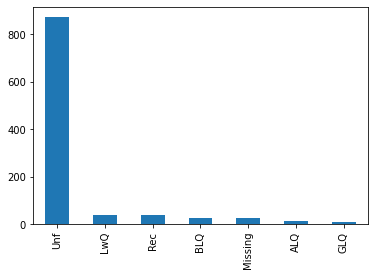

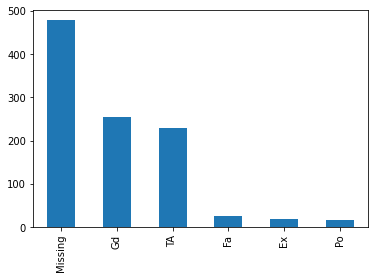

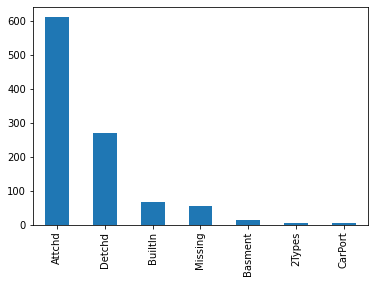

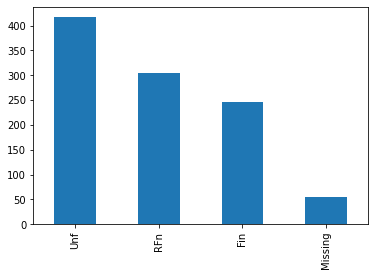

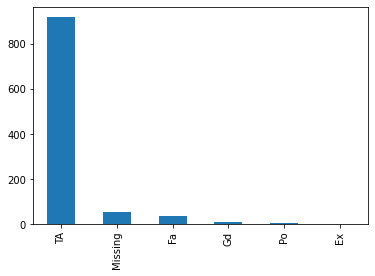

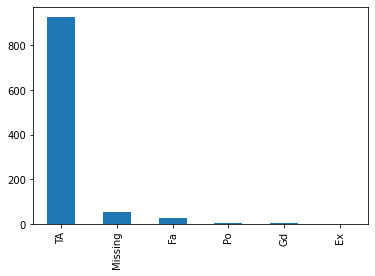

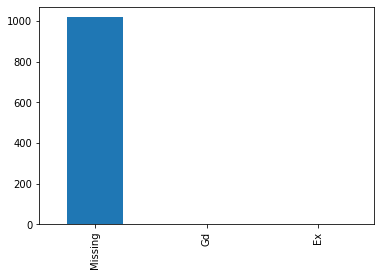

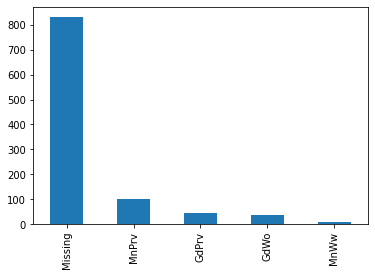

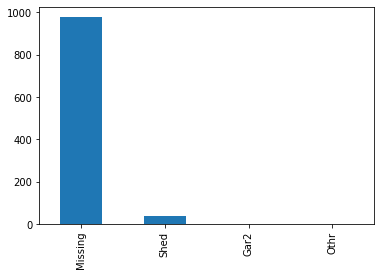

In [290]:
## Check is there any null values in categorical dataset after CategoricalImputer

for feature in categorical_with_nan:
    train_4[feature].value_counts().plot.bar() # we can see missing category has come 
    plt.show()

<div class="alert alert-info" style="background-color:#002292; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 3. Numerical or Categorical Variable Imputer </h2>
</div>

In [291]:
## Now lets check for numerical variables the contains missing values
col_with_nan=[feature for feature in x_train.columns if x_train[feature].isnull().sum()>1 ]

## We will print the numerical nan variables and percentage of missing values

for feature in col_with_nan:
    print("{}: {}% missing value".format(feature,np.around(x_train[feature].isnull().mean(),4)))

LotFrontage: 0.1849% missing value
Alley: 0.9393% missing value
MasVnrType: 0.0049% missing value
MasVnrArea: 0.0049% missing value
BsmtQual: 0.0235% missing value
BsmtCond: 0.0235% missing value
BsmtExposure: 0.0235% missing value
BsmtFinType1: 0.0235% missing value
BsmtFinType2: 0.0245% missing value
FireplaceQu: 0.4677% missing value
GarageType: 0.0528% missing value
GarageYrBlt: 0.0528% missing value
GarageFinish: 0.0528% missing value
GarageQual: 0.0528% missing value
GarageCond: 0.0528% missing value
PoolQC: 0.9971% missing value
Fence: 0.8131% missing value
MiscFeature: 0.9569% missing value


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 3.1 Random Sample Imputer </h2>
</div>

- classfeature_engine.imputation.RandomSampleImputer(random_state=None, seed='general', seeding_method='add', variables=None)

- The RandomSampleImputer() replaces missing data with a random sample extracted from the variable. 

- It works with both numerical and categorical variables. A list of variables can be indicated, or the imputer will automatically select all variables in the train set.

In [292]:
#Data copy
x_train_copy5 = x_train.copy()

# set up the imputer
#imputer = mdi.RandomSampleImputer(random_state= ['LotFrontage', 'MasVnrArea'], seed='observation', seeding_method='add')

# Here we are getting some error when use random_state = col_with_nan, so used only integer col
imputer = mdi.RandomSampleImputer(random_state= ['LotFrontage','MasVnrArea'], #col_with_nan,
                          seed='observation', # 'general'
                          seeding_method='add')
# fit the imputer
imputer.fit(x_train_copy5)

# transform the data
train_5 = imputer.transform(x_train_copy5)
#test_t = imputer.transform(X_test)

In [293]:
imputer.X_   # Copy of the training dataframe from which to extract the random samples.

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
64,65,60,RL,NaN,9375,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,NaN,0,2,2009,WD,Normal
682,683,120,RL,NaN,2887,Pave,NaN,Reg,HLS,AllPub,...,0,0,NaN,NaN,NaN,0,11,2008,WD,Normal
960,961,20,RL,50.0,7207,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
1384,1385,50,RL,60.0,9060,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,10,2009,WD,Normal
1100,1101,30,RL,60.0,8400,Pave,NaN,Reg,Bnk,AllPub,...,0,0,NaN,NaN,NaN,0,1,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,764,60,RL,82.0,9430,Pave,NaN,Reg,Lvl,AllPub,...,180,0,NaN,NaN,NaN,0,7,2009,WD,Normal
835,836,20,RL,60.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
1216,1217,90,RM,68.0,8930,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
559,560,120,RL,NaN,3196,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal


In [294]:
## Check is there any null values in categorical dataset after RandomSampleImputer
#train_5['LotFrontage'].isnull().sum() # 189 row has null values

for feature in col_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_5[feature].isnull().mean(),4)))

LotFrontage: 0.0% missing value
Alley: 0.0% missing value
MasVnrType: 0.0% missing value
MasVnrArea: 0.0% missing value
BsmtQual: 0.0% missing value
BsmtCond: 0.0% missing value
BsmtExposure: 0.0% missing value
BsmtFinType1: 0.0% missing value
BsmtFinType2: 0.0% missing value
FireplaceQu: 0.0% missing value
GarageType: 0.0% missing value
GarageYrBlt: 0.0% missing value
GarageFinish: 0.0% missing value
GarageQual: 0.0% missing value
GarageCond: 0.0% missing value
PoolQC: 0.0% missing value
Fence: 0.0% missing value
MiscFeature: 0.0% missing value


<div class="alert alert-info" style="background-color:#008492; color:white; padding:0px 10px; border-radius:2px;"><h2 style='margin:10px 5px'> 3.2 Add Missing Indicator </h2>
</div>

- It adds binary indicator as new col
- This method doesn't changes/updates any value in existing column, instead it creates the new column with missing indicator

In [295]:
#Data copy
x_train_copy6 = x_train.copy()

# set up the imputer
#addBinary_imputer = mdi.AddMissingIndicator(how='missing_only',
#     variables=['Alley', 'MasVnrType', 'LotFrontage', 'MasVnrArea'])

addBinary_imputer = mdi.AddMissingIndicator( #how='missing_only',
                                            variables=col_with_nan)

# fit the imputer
addBinary_imputer.fit(x_train_copy6)

# transform the data
train_6 = addBinary_imputer.transform(x_train_copy6)
#test_t = addBinary_imputer.transform(X_test)

In [296]:
addBinary_imputer.variables_

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [297]:
#train_6['LotFrontage'].isnull().sum() 
## Check is there any null values in categorical dataset after addBinary_imputer

for feature in categorical_with_nan:
    print("{}: {}% missing value".format(feature,np.around(train_6[feature].isnull().mean(),4)))
    
# Note that train_t also still has 189 row as null values. This is because this method doesn't changes/updates
# any value in existing column, instead it creates the new column with missing indicator

Alley: 0.9393% missing value
MasVnrType: 0.0049% missing value
BsmtQual: 0.0235% missing value
BsmtCond: 0.0235% missing value
BsmtExposure: 0.0235% missing value
BsmtFinType1: 0.0235% missing value
BsmtFinType2: 0.0245% missing value
FireplaceQu: 0.4677% missing value
GarageType: 0.0528% missing value
GarageFinish: 0.0528% missing value
GarageQual: 0.0528% missing value
GarageCond: 0.0528% missing value
PoolQC: 0.9971% missing value
Fence: 0.8131% missing value
MiscFeature: 0.9569% missing value


In [298]:
# New indicator column added as colnmae_na
train_6[['Alley_na', 'MasVnrType_na']].head()

,Alley_na,MasVnrType_na
64,1,0
682,1,0
960,1,0
1384,1,0
1100,1,0


In [299]:
train_6[['Alley','Alley_na', 'Fence','Fence_na']].tail(20)

,Alley,Alley_na,Fence,Fence_na
845,NaN,1,NaN,1
537,NaN,1,MnWw,0
849,NaN,1,NaN,1
174,NaN,1,NaN,1
87,Pave,0,NaN,1
551,NaN,1,NaN,1
705,NaN,1,NaN,1
314,Grvl,0,NaN,1
1420,NaN,1,NaN,1
600,NaN,1,NaN,1
